# 04 — SHAP Explainability

This notebook explains the threshold-corrected best model saved in Phase 3b. It loads the fitted artifact and its preprocessing without retraining. Global SHAP plots summarize contribution magnitude and direction across real held-out rows; local waterfalls explain three real predictions. No business recommendations are developed in this phase.

## Load the selected model and corrected feature space

The artifact contains fitted preprocessing, Logistic Regression, and the tuned decision threshold. The same fixed Phase 3 split is reconstructed, and the fitted preprocessor transforms it into the corrected 52-feature representation. For Logistic Regression, SHAP values are contributions on the raw log-odds scale. Numeric values displayed in SHAP plots are post-preprocessing standardized values. The module also supports `TreeExplainer` if a tree model is selected in a future run.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.explain import (
    build_local_contribution_table, compute_shap_explanations,
    load_explanation_context, plot_global_shap, plot_local_shap,
    render_explanation_summary, select_representative_rows
)

results_dir = PROJECT_ROOT / 'results'
context = load_explanation_context(
    PROJECT_ROOT / 'models' / 'best_model.joblib',
    PROJECT_ROOT / 'data',
    results_dir / 'dataset_summary.txt'
)
print('Loaded classifier:', type(context['classifier']).__name__)
print('Operational threshold:', f"{context['threshold']:.6f}")
print('Transformed test shape:', context['X_test_transformed'].shape)
print('Corrected feature names:')
print(context['feature_names'].tolist())

Loaded classifier: LogisticRegression
Operational threshold: 0.572596
Transformed test shape: (5000, 52)
Corrected feature names:
['unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'visit_day', 'device_type_0', 'device_type_1', 'device_type_2', 'user_type_0', 'user_type_1', 'marketing_channel_0', 'marketing_channel_1', 'marketing_channel_2', 'marketing_channel_3', 'marketing_channel_4', 'marketing_channel_5', 'product_category_0', 'product_category_1', 'product_category_2', 'product_category_3', 'product_category_4', 'product_category_5', 'product_category_6', 'product_category_7', 'visit_month_1', 'visit_month_2', 'visit_month_3', 'visit_month_4', 'visit_month_5', 'visit_month_6', 'visit_month_7', 'visit_month_8', 'visit_month_9', 'visit_month_10', 'visit_month_11', 'visit_month_12', 'visit_weekday_0', 'visit_weekday_1', 'visit_weekday_2', 'visit_weekday_3', 'visit_weekday_4', 'visit_weekday_5', 'visit_weekday_6', 'vi

## Select three real held-out examples

The high and low examples are the maximum and minimum predicted probabilities in the test set. The borderline example is closest to the tuned Phase 3b threshold—not an assumed cutoff of 0.5. Their actual labels remain attached for verification.

In [2]:
examples = select_representative_rows(context)
print(examples.to_string(index=False, float_format=lambda value: f'{value:.6f}'))

    example_type  test_position  source_row_index  probability  threshold  prediction  actual_label
high_probability            201              6865     0.783153   0.572596           1             1
 low_probability           2842             21403     0.000233   0.572596           0             0
      borderline           1607              2493     0.572596   0.572596           1             1


## Compute SHAP values

`LinearExplainer` uses a fixed 200-row sample from the training partition as background. Global explanations use a fixed 1,000-row held-out sample (`random_state=42`); local explanations use only the three selected rows. The classifier is not fitted again.

In [3]:
shap_results = compute_shap_explanations(context, examples)
print('Explainer used:', shap_results['explainer_name'])
print('Global SHAP array shape:', shap_results['global_explanation'].values.shape)
print('Local SHAP array shape:', shap_results['local_explanation'].values.shape)

Explainer used: LinearExplainer
Global SHAP array shape: (1000, 52)
Local SHAP array shape: (3, 52)


## Global explanations

The bar plot ranks features by mean absolute SHAP magnitude. The beeswarm adds direction: red denotes a higher transformed feature value, blue a lower value, and horizontal position shows whether the contribution raises or lowers the model output.

Saved: P:\College\Sem VII Acad\IPRM\Project\results\figures\shap_global_bar_best_model.png


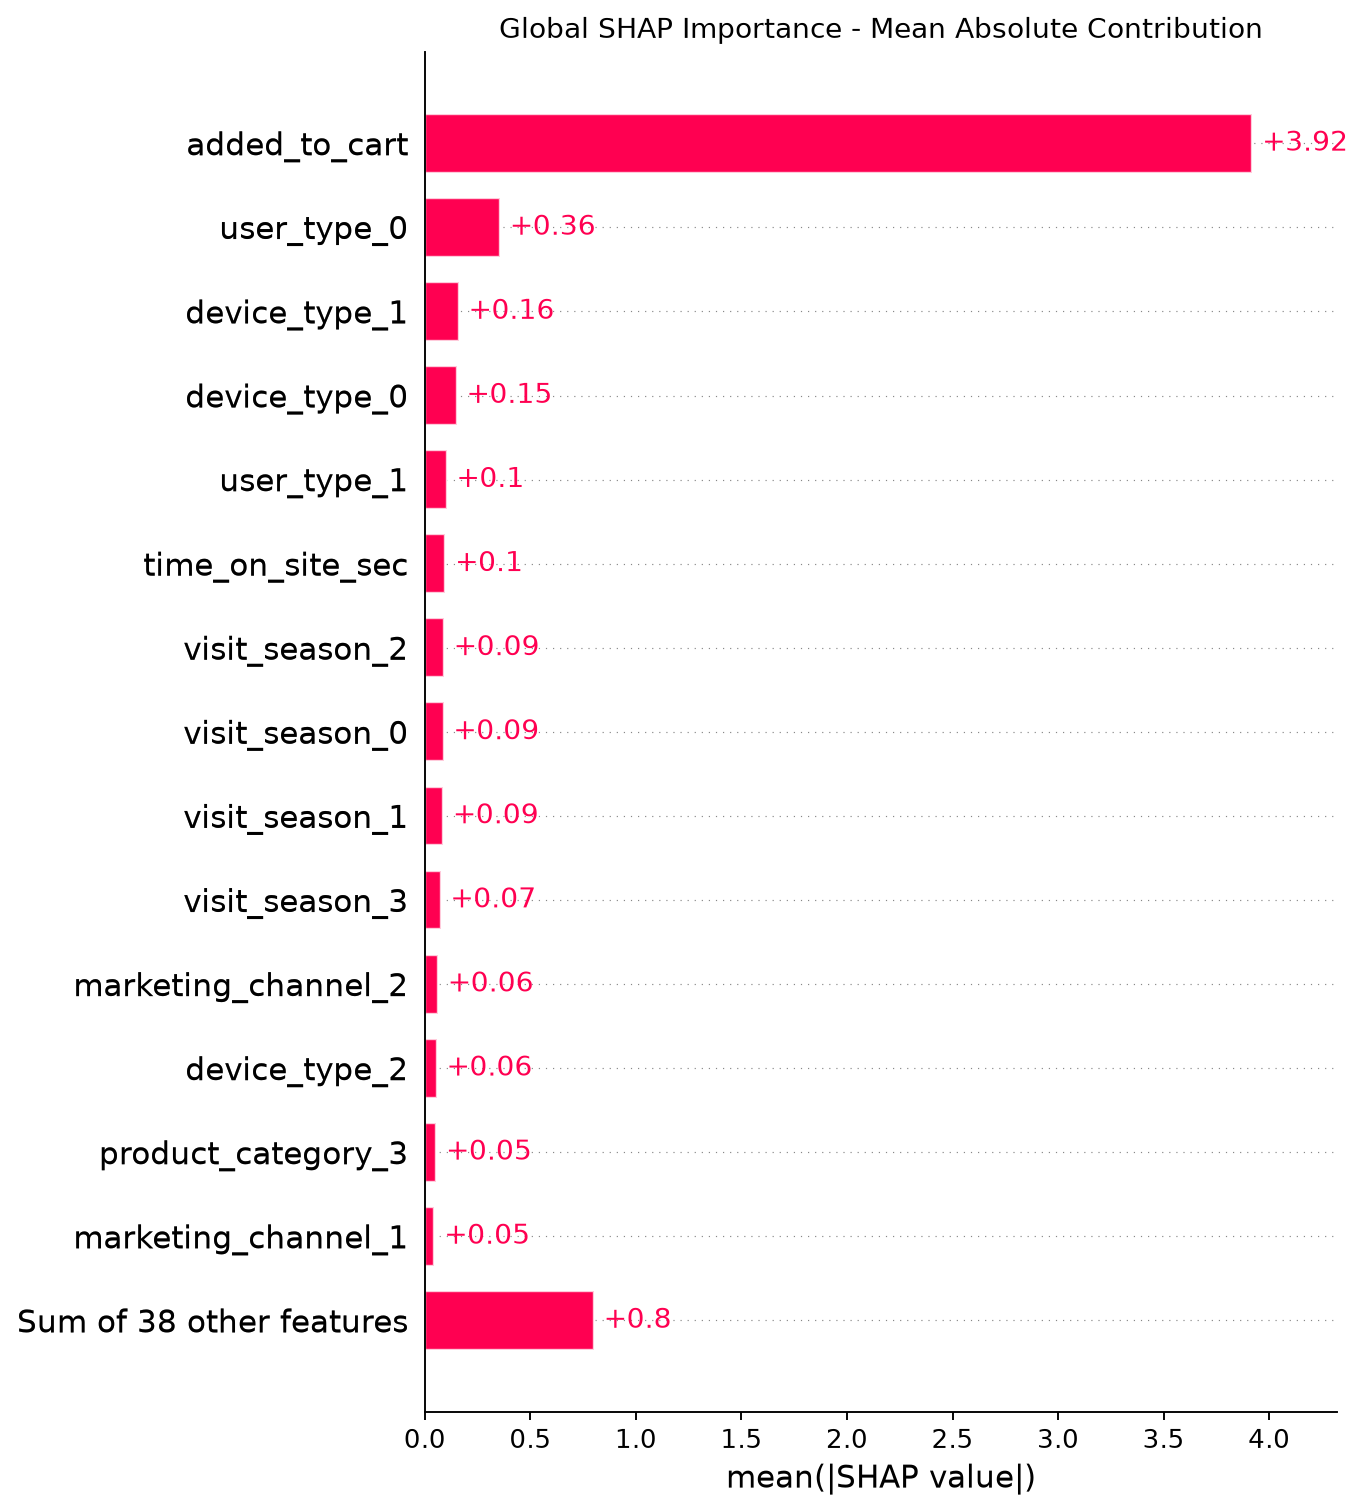

Saved: P:\College\Sem VII Acad\IPRM\Project\results\figures\shap_global_beeswarm_best_model.png


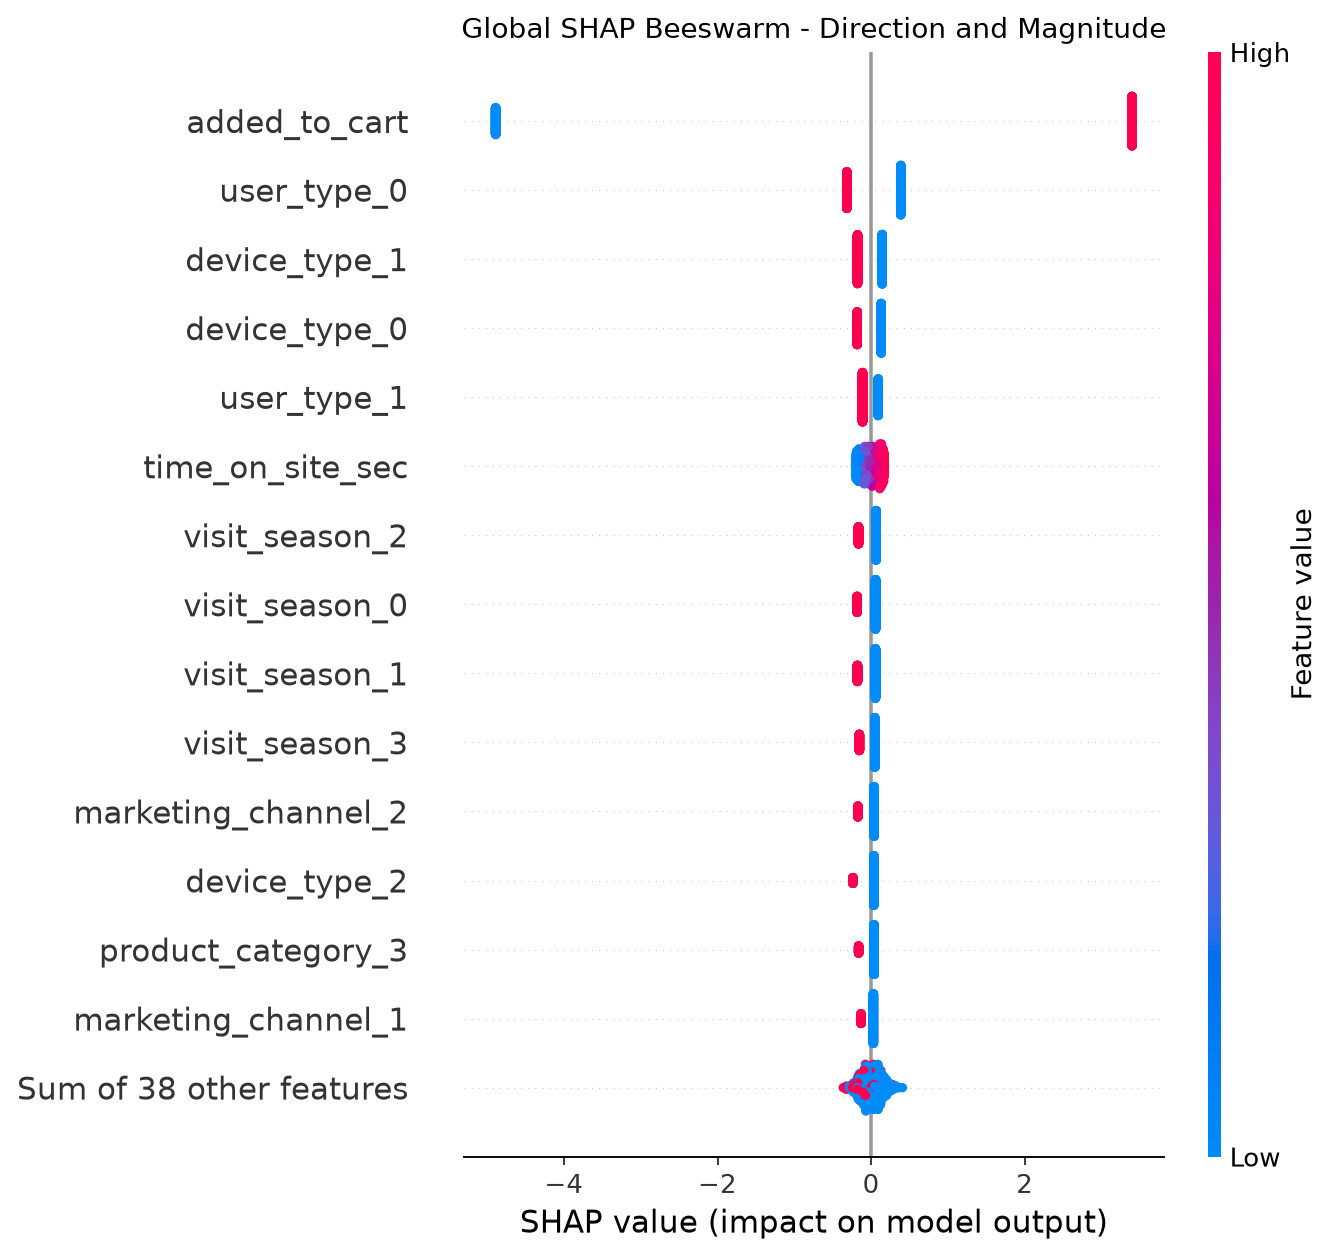

In [4]:
global_paths = plot_global_shap(shap_results, results_dir / 'figures')
for path in global_paths:
    print('Saved:', path.resolve())
    display(Image(filename=str(path)))

## Local explanations

Each waterfall starts at the explainer's expected model output and adds the row's feature contributions. Red contributions increase purchase log-odds; blue contributions decrease them. The title reports the actual probability, tuned threshold, prediction, and observed label.

Saved: P:\College\Sem VII Acad\IPRM\Project\results\figures\shap_local_high_probability.png


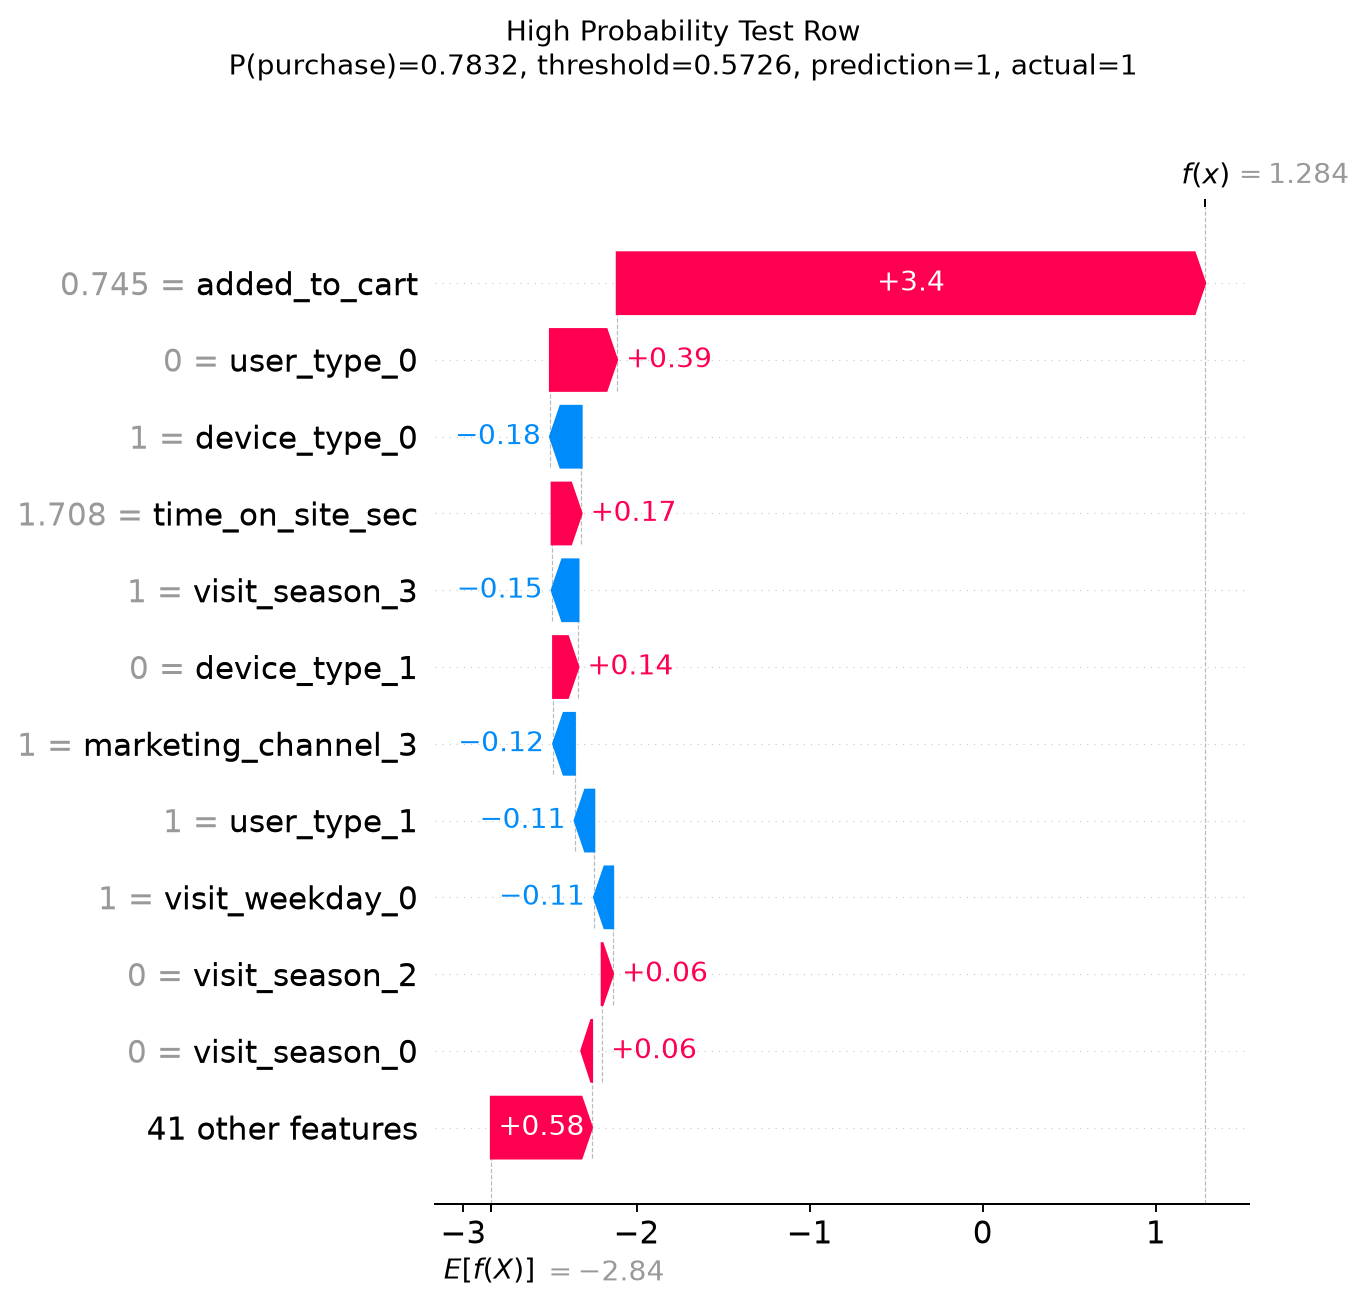

Saved: P:\College\Sem VII Acad\IPRM\Project\results\figures\shap_local_low_probability.png


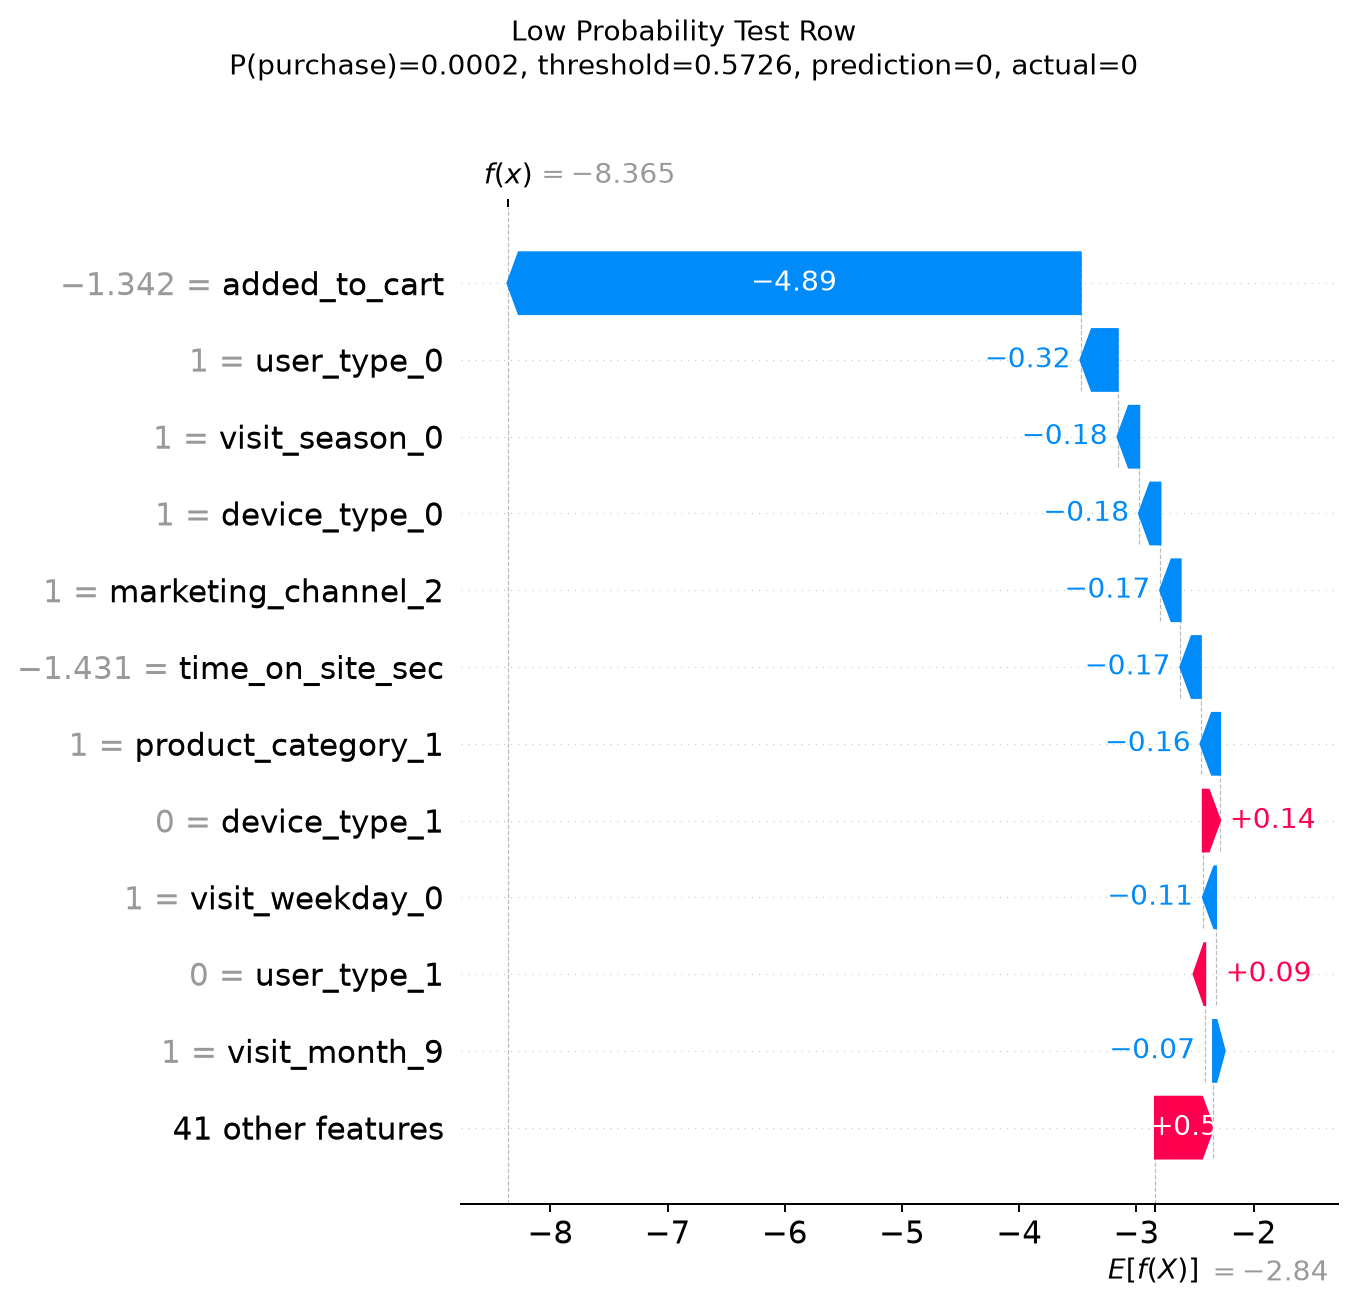

Saved: P:\College\Sem VII Acad\IPRM\Project\results\figures\shap_local_borderline.png


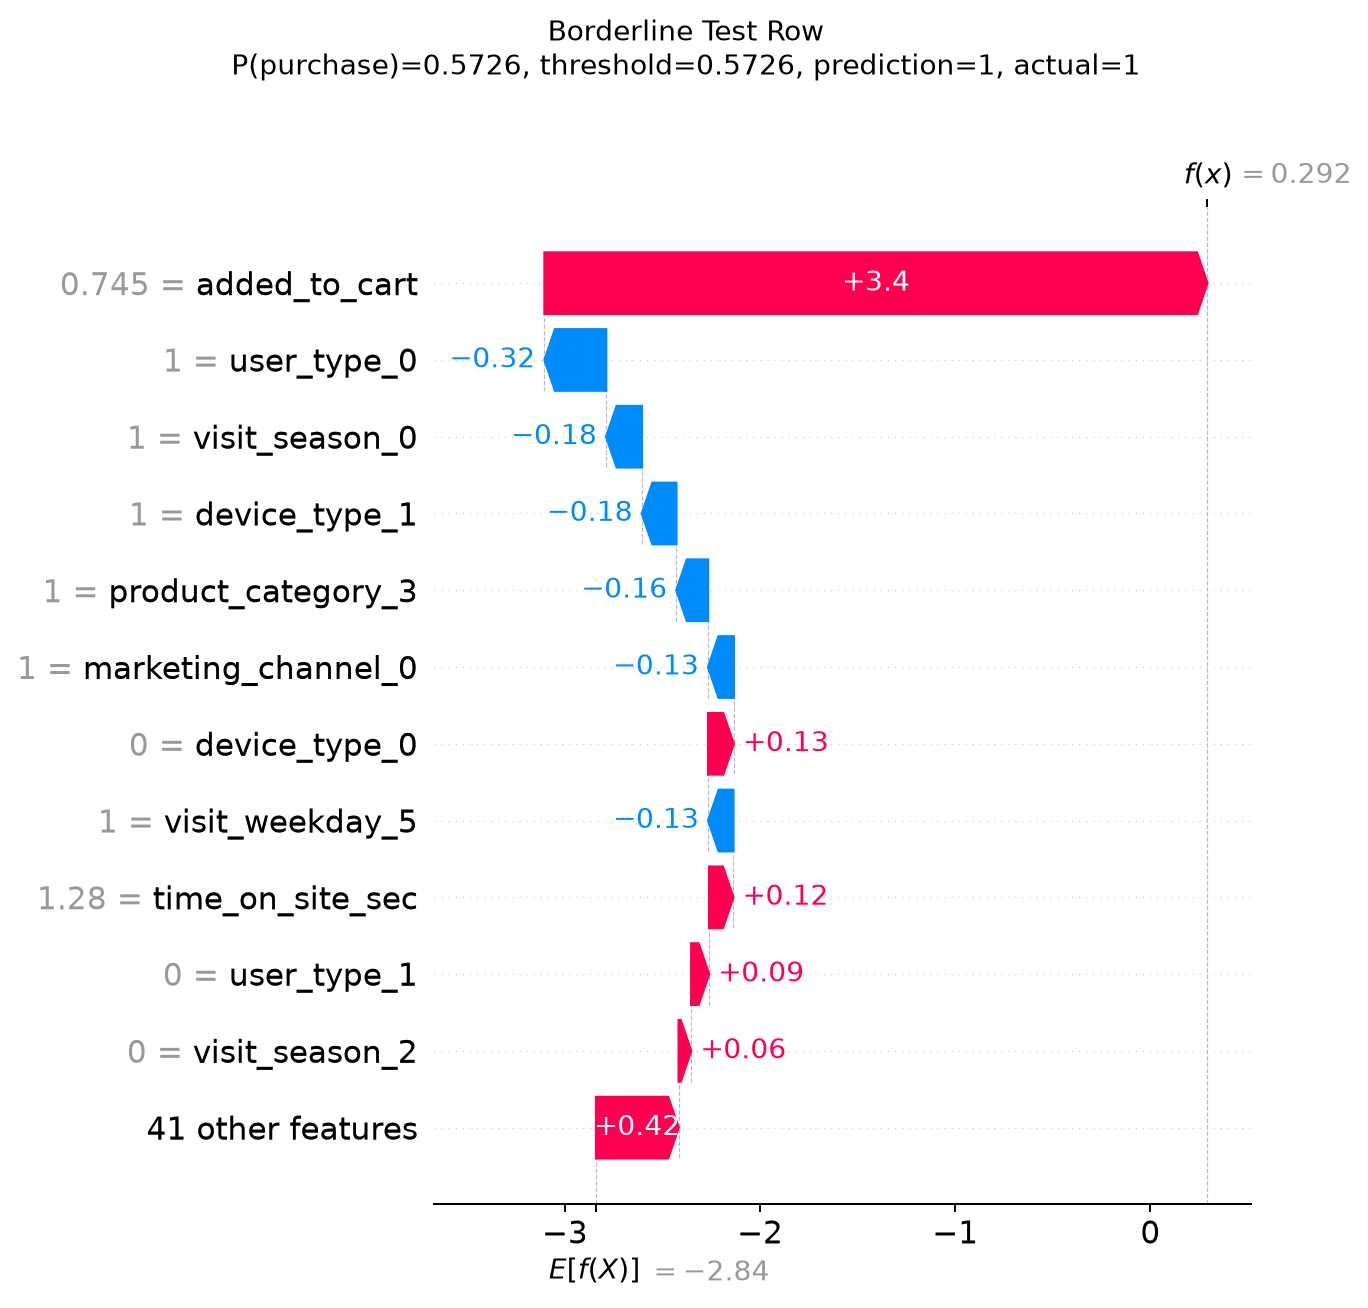

In [5]:
local_paths = plot_local_shap(
    shap_results, examples, results_dir / 'figures'
)
for path in local_paths:
    print('Saved:', path.resolve())
    display(Image(filename=str(path)))

## Top local contributions table

For each real example, the table records its prediction and actual label plus the three largest positive and three largest negative SHAP contributions. Values are calculated directly from the same local `shap.Explanation` objects used for the waterfalls.

In [6]:
contribution_table = build_local_contribution_table(
    context, shap_results, examples
)
table_path = results_dir / 'tables' / 'shap_local_examples.csv'
contribution_table.to_csv(table_path, index=False, float_format='%.8f')
print(contribution_table.to_string(index=False, float_format=lambda value: f'{value:.6f}'))
print('\nSaved table:', table_path.resolve())

    example_type  test_position  source_row_index  probability  threshold  prediction  actual_label positive_feature_1  positive_shap_1 negative_feature_1  negative_shap_1 positive_feature_2  positive_shap_2 negative_feature_2  negative_shap_2 positive_feature_3  positive_shap_3  negative_feature_3  negative_shap_3
high_probability            201              6865     0.783153   0.572596           1             1      added_to_cart         3.397188      device_type_0        -0.181131        user_type_0         0.386177     visit_season_3        -0.153099   time_on_site_sec         0.171267 marketing_channel_3        -0.123788
 low_probability           2842             21403     0.000233   0.572596           0             0      device_type_1         0.144659      added_to_cart        -4.888636        user_type_1         0.091694        user_type_0        -0.315963     visit_season_2         0.064132      visit_season_0        -0.183040
      borderline           1607              2493

## Save the Phase 4 execution summary

The summary records the loaded model family, explainer, operational threshold, feature count, sampled rows, real local contributions, and generated figure paths.

In [7]:
summary = render_explanation_summary(
    context, shap_results, examples, contribution_table,
    [*global_paths, *local_paths]
)
summary_path = results_dir / 'shap_explainability_summary.txt'
summary_path.write_text(summary, encoding='utf-8')
print('Saved Phase 4 summary:', summary_path.resolve())
print('No business-insight analysis was performed.')

Saved Phase 4 summary: P:\College\Sem VII Acad\IPRM\Project\results\shap_explainability_summary.txt
No business-insight analysis was performed.


## Phase 4 boundary

Global and local SHAP explanations are complete. Business interpretation, recommendations, and later adaptive experiments are intentionally deferred.